<a href="https://colab.research.google.com/github/LuisG-S/FMU_2026_TecnicasDeMachineLearning_Locadora/blob/main/locadora_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Machine Learning N1 - BCC noturno

## Integrantes

Luis Sauer - 2025113866

Matheus Pereira - 2025114396

Thiago Dantas - 2025103920

Atylla Dias - 2025114071

Bruno Oliveira - 2025115009


# 🚗 Machine Learning aplicado a uma Locadora de Veículos

## Objetivo do projeto

Nesse notebook vamos simular um problema real de negócio:

> **A locadora quer prever se um cliente vai devolver o carro no prazo ou vai atrasar.**

Isso é útil porque atrasos custam dinheiro (carro indisponível, multas, renegociação). Se o sistema conseguir identificar clientes com maior risco de atraso, a empresa pode tomar ações preventivas — como cobrar uma caução extra, mandar um lembrete, etc.

### O que vamos fazer:
1. Gerar dados fictícios (mas realistas) de aluguéis
2. Explorar e entender os dados (EDA)
3. Preparar os dados para o modelo
4. Treinar dois modelos de classificação
5. Comparar os resultados e interpretar

---
> **Tipo de problema:** Classificação binária (0 = atrasou, 1 = devolveu no prazo)

## 1. Importando as bibliotecas

Antes de tudo, importamos tudo que vamos usar. Nada de novo aqui — `pandas` para manipular dados, `sklearn` para o ML, e `matplotlib`/`seaborn` para os gráficos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

# Deixa os gráficos bonitinhos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Semente aleatória — garante que os dados gerados sejam sempre iguais
np.random.seed(42)

print('Tudo importado com sucesso! ✅')

Tudo importado com sucesso! ✅


---
## 2. Gerando os dados fictícios

Como não temos dados reais, vamos criar um dataset simulado com **1.500 registros de aluguel**.

Cada linha representa um aluguel diferente, com as seguintes colunas:

| Coluna | Descrição |
|---|---|
| `idade_cliente` | Idade do cliente (18–70 anos) |
| `categoria_veiculo` | Tipo de carro alugado |
| `dias_aluguel` | Quantos dias o carro foi alugado |
| `km_estimado` | Quilometragem estimada pelo cliente |
| `temporada` | Alta ou baixa temporada |
| `historico_atrasos` | Quantas vezes esse cliente já atrasou antes |
| `seguro_contratado` | Se contratou o seguro ou não |
| `forma_pagamento` | Como pagou |
| `valor_diaria` | Valor da diária em reais |
| `devolveu_no_prazo` | **TARGET**: 1 = devolveu no prazo, 0 = atrasou |

In [ ]:
N = 1500

# --- Features (variáveis de entrada) ---
idade_cliente     = np.random.randint(18, 71, N)
categoria_veiculo = np.random.choice(['Econômico', 'Intermediário', 'SUV', 'Luxo'],
                                      N, p=[0.40, 0.30, 0.20, 0.10])
dias_aluguel      = np.random.randint(1, 31, N)
km_estimado       = np.random.randint(100, 3001, N)
temporada         = np.random.choice(['Alta', 'Baixa'], N, p=[0.45, 0.55])
historico_atrasos = np.random.choice([0, 1, 2, 3, 4, 5], N, p=[0.50, 0.25, 0.12, 0.07, 0.04, 0.02])
seguro_contratado = np.random.choice([0, 1], N, p=[0.35, 0.65])
forma_pagamento   = np.random.choice(['Crédito', 'Débito', 'PIX'], N, p=[0.50, 0.25, 0.25])

# Valor da diária varia conforme a categoria
preco_base = {'Econômico': 120, 'Intermediário': 200, 'SUV': 320, 'Luxo': 550}
valor_diaria = np.array([
    preco_base[cat] + np.random.randint(-30, 60)
    for cat in categoria_veiculo
])

# --- Target: devolveu_no_prazo ---
# A lógica abaixo simula o mundo real:
#   - Mais atrasos no histórico → mais chance de atrasar
#   - Alta temporada → mais caos → mais atraso
#   - Aluguéis muito longos → mais chance de atraso
#   - Seguro contratado → cliente mais responsável → menos atraso (correlação fraca)

prob_atraso = (
    0.05
    + historico_atrasos * 0.12           # histórico pesa bastante
    + (temporada == 'Alta') * 0.08       # alta temporada aumenta risco
    + (dias_aluguel > 15) * 0.07         # aluguel longo aumenta risco
    - seguro_contratado * 0.05           # seguro reduz levemente
    + np.random.uniform(0, 0.1, N)       # componente aleatório
)
prob_atraso = np.clip(prob_atraso, 0, 1)
devolveu_no_prazo = (np.random.uniform(0, 1, N) > prob_atraso).astype(int)

# --- Montando o DataFrame ---
df = pd.DataFrame({
    'idade_cliente':     idade_cliente,
    'categoria_veiculo': categoria_veiculo,
    'dias_aluguel':      dias_aluguel,
    'km_estimado':       km_estimado,
    'temporada':         temporada,
    'historico_atrasos': historico_atrasos,
    'seguro_contratado': seguro_contratado,
    'forma_pagamento':   forma_pagamento,
    'valor_diaria':      valor_diaria,
    'devolveu_no_prazo': devolveu_no_prazo
})

print(f'Dataset criado! Shape: {df.shape}')
df.head(10)

Dataset criado! Shape: (1500, 10)


,idade_cliente,categoria_veiculo,dias_aluguel,km_estimado,temporada,historico_atrasos,seguro_contratado,forma_pagamento,valor_diaria,devolveu_no_prazo
0,56,SUV,10,594,Baixa,3,1,Crédito,351,0
1,69,Intermediário,19,1747,Baixa,1,0,Crédito,211,0
2,46,SUV,18,2042,Baixa,1,1,Crédito,372,1
3,32,SUV,6,1168,Alta,0,1,Débito,358,1
4,60,Intermediário,27,1524,Baixa,1,0,Crédito,227,1
5,25,Econômico,29,696,Baixa,0,1,PIX,94,1
6,38,Econômico,15,549,Baixa,0,1,Crédito,116,1
7,56,Intermediário,21,584,Alta,1,0,PIX,197,1
8,36,Intermediário,30,745,Alta,0,0,Crédito,195,0
9,40,Econômico,10,2767,Alta,2,1,PIX,138,0


---
## 3. Análise Exploratória (EDA)

Antes de qualquer modelo, o passo mais importante é **entender os dados**. Aqui vamos checar:
- Se tem valores faltando
- Como as variáveis estão distribuídas
- Se existe desequilíbrio na variável alvo (target)

In [ ]:
print('=== Informações gerais ===')
df.info()
print()
print('=== Valores nulos por coluna ===')
print(df.isnull().sum())

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   idade_cliente      1500 non-null   int64 
 1   categoria_veiculo  1500 non-null   object
 2   dias_aluguel       1500 non-null   int64 
 3   km_estimado        1500 non-null   int64 
 4   temporada          1500 non-null   object
 5   historico_atrasos  1500 non-null   int64 
 6   seguro_contratado  1500 non-null   int64 
 7   forma_pagamento    1500 non-null   object
 8   valor_diaria       1500 non-null   int64 
 9   devolveu_no_prazo  1500 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 117.3+ KB

=== Valores nulos por coluna ===
idade_cliente        0
categoria_veiculo    0
dias_aluguel         0
km_estimado          0
temporada            0
historico_atrasos    0
seguro_contratado    0
forma_pagamento      0
valor_diaria         0
devolveu_

In [ ]:
print('=== Estatísticas descritivas ===')
df.describe().round(2)

=== Estatísticas descritivas ===


,idade_cliente,dias_aluguel,km_estimado,historico_atrasos,seguro_contratado,valor_diaria,devolveu_no_prazo
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,44.26,15.61,1539.03,0.95,0.63,240.38,0.73
std,15.37,8.62,840.38,1.25,0.48,129.27,0.45
min,18.00,1.00,102.00,0.00,0.00,90.00,0.00
25%,31.00,8.00,817.75,0.00,0.00,148.00,0.00
50%,45.00,16.00,1538.00,0.00,1.00,200.00,1.00
75%,57.00,23.00,2255.25,2.00,1.00,309.25,1.00
max,70.00,30.00,2999.00,5.00,1.00,609.00,1.00


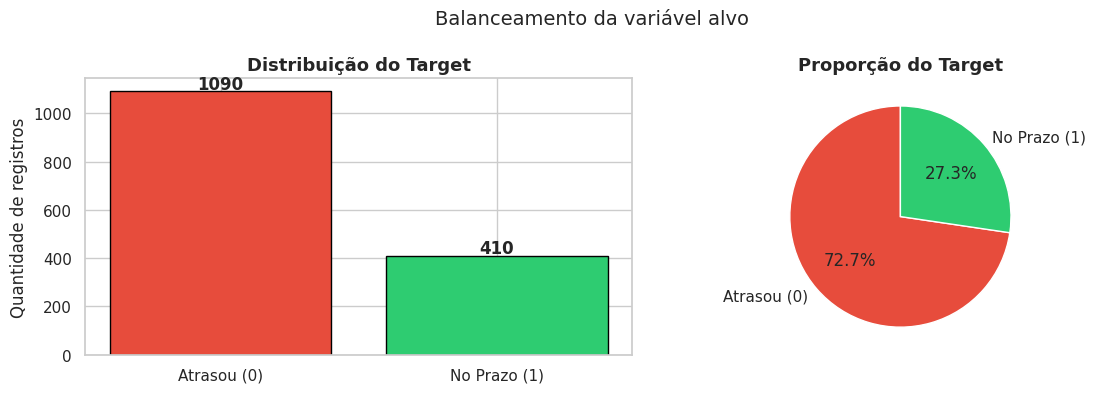


Porcentagem que devolveu no prazo: 72.7%
Porcentagem que atrasou:           27.3%


In [ ]:
# Verificando o balanceamento do target
contagem = df['devolveu_no_prazo'].value_counts()
labels   = ['Atrasou (0)', 'No Prazo (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, contagem.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribuição do Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de registros')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(contagem.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporção do Target', fontsize=13, fontweight='bold')

plt.suptitle('Balanceamento da variável alvo', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nPorcentagem que devolveu no prazo: {contagem[1]/N*100:.1f}%')
print(f'Porcentagem que atrasou:           {contagem[0]/N*100:.1f}%')

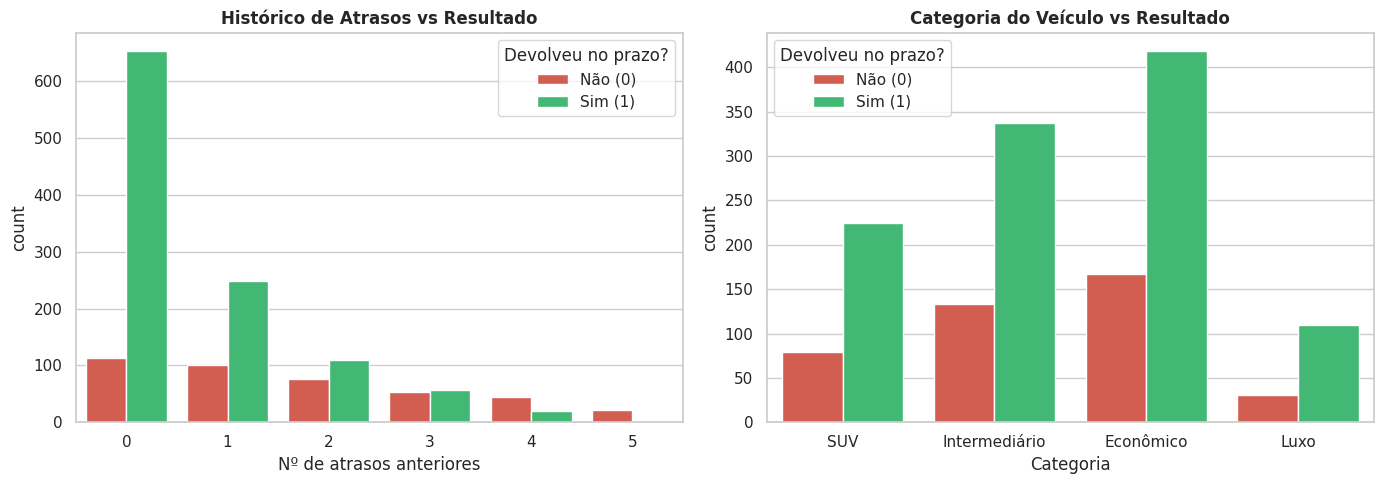

In [ ]:
# Relação entre histórico de atrasos e a entrega no prazo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histórico de atrasos vs Target
sns.countplot(data=df, x='historico_atrasos', hue='devolveu_no_prazo',
              palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[0])
axes[0].set_title('Histórico de Atrasos vs Resultado', fontweight='bold')
axes[0].set_xlabel('Nº de atrasos anteriores')
axes[0].legend(title='Devolveu no prazo?', labels=['Não (0)', 'Sim (1)'])

# Gráfico 2: Categoria do veículo vs Target
sns.countplot(data=df, x='categoria_veiculo', hue='devolveu_no_prazo',
              palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[1])
axes[1].set_title('Categoria do Veículo vs Resultado', fontweight='bold')
axes[1].set_xlabel('Categoria')
axes[1].legend(title='Devolveu no prazo?', labels=['Não (0)', 'Sim (1)'])

plt.tight_layout()
plt.show()

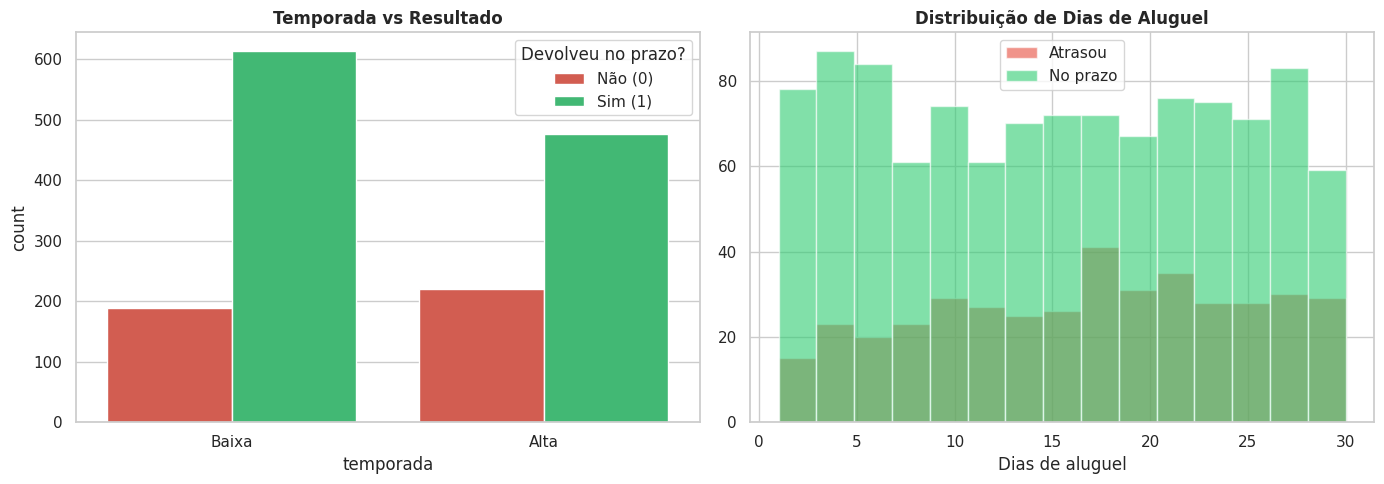

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 3: Temporada
sns.countplot(data=df, x='temporada', hue='devolveu_no_prazo',
              palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[0])
axes[0].set_title('Temporada vs Resultado', fontweight='bold')
axes[0].legend(title='Devolveu no prazo?', labels=['Não (0)', 'Sim (1)'])

# Gráfico 4: Dias de aluguel (distribuição por classe)
df[df['devolveu_no_prazo'] == 0]['dias_aluguel'].hist(
    ax=axes[1], alpha=0.6, label='Atrasou', color='#e74c3c', bins=15)
df[df['devolveu_no_prazo'] == 1]['dias_aluguel'].hist(
    ax=axes[1], alpha=0.6, label='No prazo', color='#2ecc71', bins=15)
axes[1].set_title('Distribuição de Dias de Aluguel', fontweight='bold')
axes[1].set_xlabel('Dias de aluguel')
axes[1].legend()

plt.tight_layout()
plt.show()

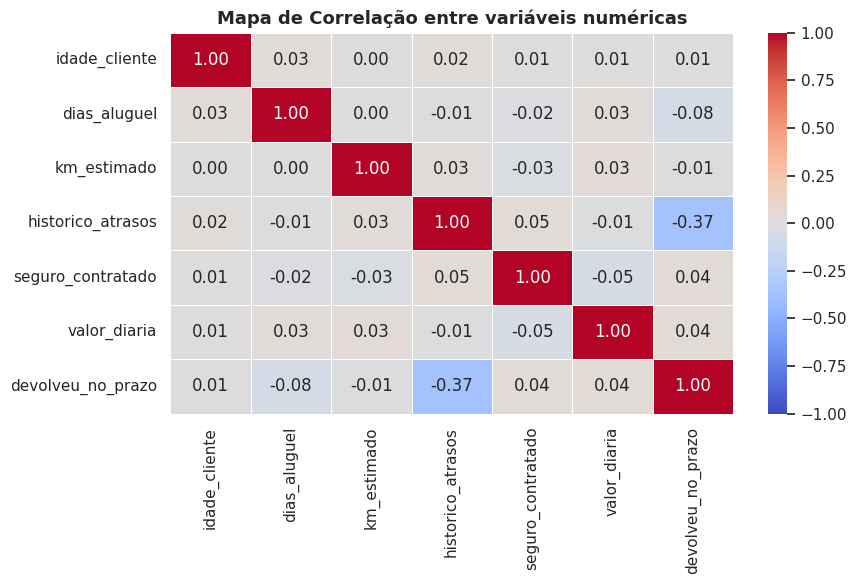


💡 Dica: valores próximos de -1 ou 1 indicam forte correlação.
   historico_atrasos tem correlação negativa com devolveu_no_prazo — faz sentido!


In [ ]:
# Mapa de correlação — só funciona com colunas numéricas
numericas = df[['idade_cliente', 'dias_aluguel', 'km_estimado',
                'historico_atrasos', 'seguro_contratado',
                'valor_diaria', 'devolveu_no_prazo']]

plt.figure(figsize=(9, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Correlação entre variáveis numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('💡 Dica: valores próximos de -1 ou 1 indicam forte correlação.')
print('   historico_atrasos tem correlação negativa com devolveu_no_prazo — faz sentido!')

---
## 4. Pré-processamento

Os modelos de ML só entendem **números**. Por isso precisamos:
- Transformar colunas de texto (categorias) em números → **Label Encoding**
- Separar o dataset em features (`X`) e target (`y`)
- Dividir em **treino** e **teste**
- **Normalizar** as colunas numéricas para que nenhuma variável domine as outras por causa da escala

In [ ]:
df_model = df.copy()

# Colunas categóricas que precisam virar número
colunas_categoricas = ['categoria_veiculo', 'temporada', 'forma_pagamento']

le = LabelEncoder()
for col in colunas_categoricas:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'{col}: {dict(enumerate(le.classes_))}')

print('\nDataset após encoding:')
df_model.head(5)

categoria_veiculo: {0: 'Econômico', 1: 'Intermediário', 2: 'Luxo', 3: 'SUV'}
temporada: {0: 'Alta', 1: 'Baixa'}
forma_pagamento: {0: 'Crédito', 1: 'Débito', 2: 'PIX'}

Dataset após encoding:


,idade_cliente,categoria_veiculo,dias_aluguel,km_estimado,temporada,historico_atrasos,seguro_contratado,forma_pagamento,valor_diaria,devolveu_no_prazo
0,56,3,10,594,1,3,1,0,351,0
1,69,1,19,1747,1,1,0,0,211,0
2,46,3,18,2042,1,1,1,0,372,1
3,32,3,6,1168,0,0,1,1,358,1
4,60,1,27,1524,1,1,0,0,227,1


In [ ]:
# Separando X (features) e y (target)
X = df_model.drop(columns=['devolveu_no_prazo'])
y = df_model['devolveu_no_prazo']

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino:  {X_train.shape[0]} amostras ({X_train.shape[0]/N*100:.0f}%)')
print(f'Teste:   {X_test.shape[0]} amostras ({X_test.shape[0]/N*100:.0f}%)')

Treino:  1200 amostras (80%)
Teste:   300 amostras (20%)


In [ ]:
# Normalizando (StandardScaler: média 0, desvio padrão 1)
# Importante: o scaler aprende com o TREINO e aplica no TESTE
# (para não vazar informação do teste pro treino)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Normalização aplicada! ✅')
print(f'Média das features no treino (deve ser ≈ 0): {X_train_scaled.mean(axis=0).round(2)}')

Normalização aplicada! ✅
Média das features no treino (deve ser ≈ 0): [-0.  0.  0.  0. -0. -0.  0. -0.  0.]


---
## 5. Treinando os Modelos

Vamos testar dois modelos clássicos de classificação:

### 📌 Modelo 1: Regressão Logística
Apesar do nome "regressão", ela é usada pra **classificação**. Ela calcula a probabilidade de cada classe usando uma função sigmoide. É simples, rápida e interpretável — ótima pra ter uma baseline.

### 🌲 Modelo 2: Random Forest
Cria várias árvores de decisão e combina o resultado delas (votação). Tende a ser mais precisa que a Regressão Logística e lida bem com relações não-lineares.

In [ ]:
# -------- Modelo 1: Regressão Logística --------
print('Treinando Regressão Logística...')
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(f'\nAcurácia (Regressão Logística): {accuracy_score(y_test, y_pred_lr):.4f}')
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_lr, target_names=['Atrasou', 'No Prazo']))

Treinando Regressão Logística...

Acurácia (Regressão Logística): 0.7500

Relatório de Classificação:
              precision    recall  f1-score   support

     Atrasou       0.61      0.23      0.34        82
    No Prazo       0.77      0.94      0.85       218

    accuracy                           0.75       300
   macro avg       0.69      0.59      0.59       300
weighted avg       0.72      0.75      0.71       300



In [ ]:
# -------- Modelo 2: Random Forest --------
print('Treinando Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print(f'\nAcurácia (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_rf, target_names=['Atrasou', 'No Prazo']))

Treinando Random Forest...

Acurácia (Random Forest): 0.7000

Relatório de Classificação:
              precision    recall  f1-score   support

     Atrasou       0.39      0.17      0.24        82
    No Prazo       0.74      0.90      0.81       218

    accuracy                           0.70       300
   macro avg       0.57      0.53      0.53       300
weighted avg       0.65      0.70      0.66       300



---
## 6. Avaliando os Modelos

A acurácia sozinha pode enganar — especialmente quando as classes estão desbalanceadas. Por isso também olhamos:

| Métrica | O que significa? |
|---|---|
| **Precision** | Dos que o modelo disse que iam atrasar, quantos realmente atrasaram? |
| **Recall** | Dos que realmente atrasaram, quantos o modelo identificou? |
| **F1-Score** | Média harmônica entre Precision e Recall |
| **Confusion Matrix** | Mostra onde o modelo errou e acertou |

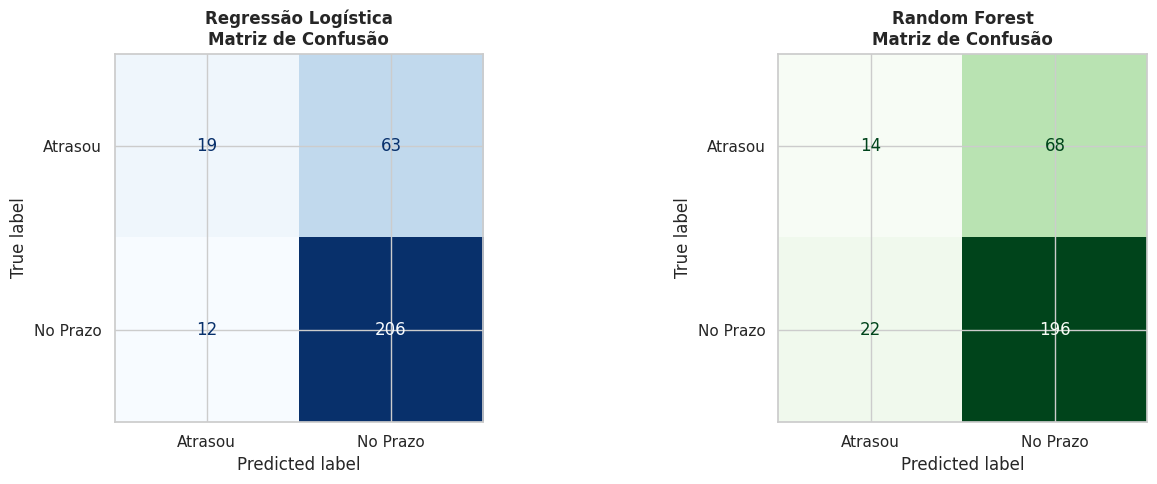


💡 Lendo a matriz:
   Linha = o que aconteceu de verdade | Coluna = o que o modelo previu
   Diagonal principal = acertos | Fora da diagonal = erros


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão - Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Atrasou', 'No Prazo'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Regressão Logística\nMatriz de Confusão', fontweight='bold', fontsize=12)

# Matriz de Confusão - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Atrasou', 'No Prazo'])
disp_rf.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest\nMatriz de Confusão', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print()
print('💡 Lendo a matriz:')
print('   Linha = o que aconteceu de verdade | Coluna = o que o modelo previu')
print('   Diagonal principal = acertos | Fora da diagonal = erros')

=== Comparação dos Modelos ===
                     Acurácia  Precision  Recall  F1-Score
Modelo                                                    
Regressão Logística      0.75     0.7658  0.9450    0.8460
Random Forest            0.70     0.7424  0.8991    0.8133


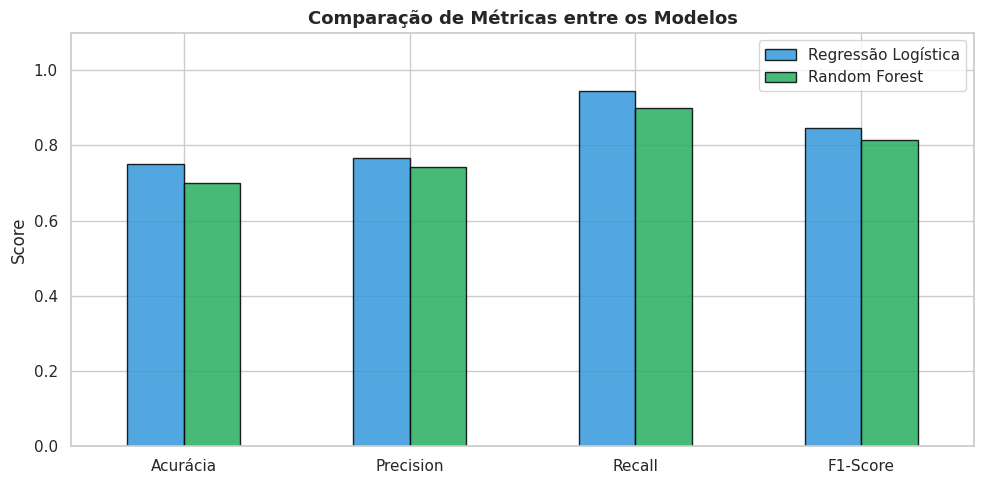

In [ ]:
# Comparação final entre os dois modelos
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia':  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    'F1-Score':  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)],
})

print('=== Comparação dos Modelos ===')
print(resultados.set_index('Modelo').round(4).to_string())

# Gráfico de barras comparando as métricas
resultados_plot = resultados.set_index('Modelo').T
resultados_plot.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#27ae60'],
                     edgecolor='black', alpha=0.85)
plt.title('Comparação de Métricas entre os Modelos', fontweight='bold', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Importância das Features (Random Forest)

Uma das coisas legais do Random Forest é que ele consegue medir **o quanto cada variável contribuiu** para as decisões do modelo. Isso ajuda a entender o que de fato importa pra prever o atraso.

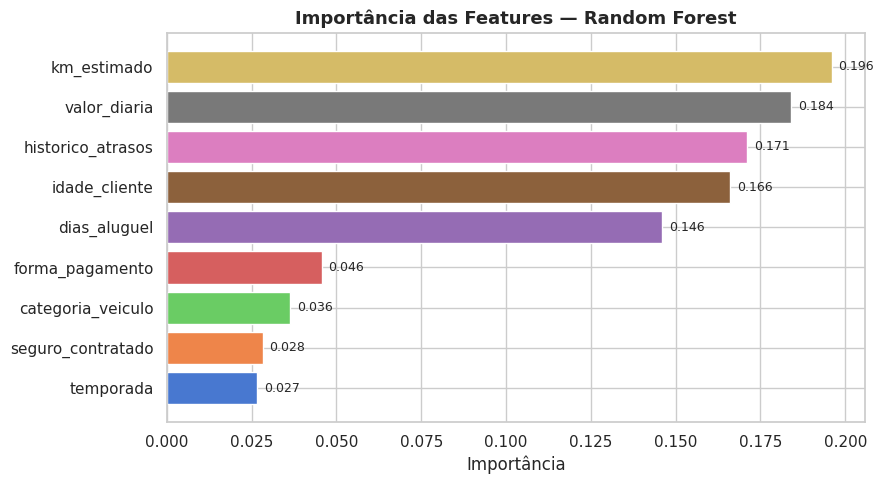


🏆 Feature mais importante: km_estimado (0.196)
📉 Feature menos importante: temporada (0.027)


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(importancias.index, importancias.values,
                color=sns.color_palette('muted', len(importancias)))
plt.xlabel('Importância')
plt.title('Importância das Features — Random Forest', fontweight='bold', fontsize=13)
for bar, val in zip(bars, importancias.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\n🏆 Feature mais importante: {importancias.idxmax()} ({importancias.max():.3f})')
print(f'📉 Feature menos importante: {importancias.idxmin()} ({importancias.min():.3f})')

---
## 8. Testando com um cliente fictício

Agora vamos simular uma previsão pra um cliente específico — como se fosse na prática.

In [ ]:
# Encodings gerados pelo LabelEncoder:
#   categoria_veiculo: Econômico=1, Intermediário=2, Luxo=3, SUV=4
#   forma_pagamento:   Crédito=0, Débito=1, PIX=2
#   temporada:         Alta=0, Baixa=1

novo_cliente = pd.DataFrame([{
    'idade_cliente':     35,
    'categoria_veiculo': 1,      # Econômico
    'dias_aluguel':      7,
    'km_estimado':       500,
    'temporada':         1,      # Baixa
    'historico_atrasos': 1,      # Já atrasou 1 vez
    'seguro_contratado': 1,      # Contratou seguro
    'forma_pagamento':   0,      # Crédito
    'valor_diaria':      130,
}])

novo_scaled = scaler.transform(novo_cliente)

pred_lr = lr.predict(novo_scaled)[0]
prob_lr = lr.predict_proba(novo_scaled)[0]

pred_rf = rf.predict(novo_scaled)[0]
prob_rf = rf.predict_proba(novo_scaled)[0]

print('=== Previsão para o novo cliente ===')
print()
print(f'[Regressão Logística]')
print(f'  Previsão:    {"✅ Devolverá no prazo" if pred_lr == 1 else "⚠️ Risco de atraso"}')
print(f'  Prob. atraso: {prob_lr[0]*100:.1f}% | Prob. no prazo: {prob_lr[1]*100:.1f}%')
print()
print(f'[Random Forest]')
print(f'  Previsão:    {"✅ Devolverá no prazo" if pred_rf == 1 else "⚠️ Risco de atraso"}')
print(f'  Prob. atraso: {prob_rf[0]*100:.1f}% | Prob. no prazo: {prob_rf[1]*100:.1f}%')

=== Previsão para o novo cliente ===

[Regressão Logística]
  Previsão:    ✅ Devolverá no prazo
  Prob. atraso: 17.8% | Prob. no prazo: 82.2%

[Random Forest]
  Previsão:    ✅ Devolverá no prazo
  Prob. atraso: 44.0% | Prob. no prazo: 56.0%


---
## 9. Conclusão — Parte 1

### O que fizemos:
- ✅ Geramos um dataset fictício com lógica de negócio embutida
- ✅ Exploramos os dados visualmente (EDA)
- ✅ Aplicamos pré-processamento (encoding + normalização)
- ✅ Treinamos dois modelos: **Regressão Logística** e **Random Forest**
- ✅ Avaliamos com métricas: acurácia, precision, recall, F1, matriz de confusão
- ✅ Visualizamos a importância das features

### Interpretando os resultados:
- A variável `historico_atrasos` foi de longe a mais importante, como esperado
- O **Random Forest** tende a ter performance ligeiramente superior à Regressão Logística
- A Regressão Logística é mais simples e fácil de interpretar — boa pra explicar pra um gestor

---
---
# 🚨 PARTE 2 — Detecção de Fraude

## O problema é diferente (e mais difícil!)

Na Parte 1, as classes eram relativamente equilibradas (~70% no prazo, ~30% atrasou). Isso facilita a vida do modelo.

Na detecção de fraude, a realidade é cruel: **fraudes são raras**. Numa locadora, talvez só 2–3% dos aluguéis sejam fraudulentos. Isso cria o chamado **problema de desbalanceamento de classes**.

### Por que isso é um problema?

> Imagina um modelo que simplesmente responde **"não é fraude"** pra tudo. Ele vai ter **97% de acurácia** — e vai ser completamente inútil. Nunca vai pegar uma fraude sequer.

Então nessa parte vamos aprender a lidar com isso usando duas estratégias:
1. **`class_weight='balanced'`** — penaliza mais os erros na classe minoritária
2. **SMOTE** — cria amostras sintéticas da classe minoritária pra equilibrar o dataset

### Cenário de fraude simulado:
A locadora quer identificar **transações suspeitas no momento do aluguel**, com base em sinais como:
- Valor total muito alto pra um cliente novo
- Muitas tentativas de pagamento
- Documento não verificado
- Cidade de devolução diferente da retirada
- Km rodado muito acima do estimado

In [ ]:
# Instalando a biblioteca de SMOTE (pode demorar alguns segundos no Colab)
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

print('Bibliotecas de fraude carregadas! ✅')

Bibliotecas de fraude carregadas! ✅


---
## 10. Gerando os dados de fraude

Vamos criar um novo dataset com **2.000 transações**, onde apenas **~3% são fraudulentas**.

| Coluna | Descrição |
|---|---|
| `valor_total` | Valor total da transação (diária × dias) |
| `tentativas_pagamento` | Quantas vezes tentou pagar antes de conseguir |
| `cliente_novo` | 1 = nunca alugou antes, 0 = cliente antigo |
| `documento_verificado` | 1 = documento OK, 0 = não verificado |
| `cidade_diferente` | 1 = quer devolver em outra cidade |
| `ratio_km` | km_real ÷ km_estimado (muito alto = suspeito) |
| `hora_contrato` | Hora do dia em que fechou o contrato |
| `forma_pagamento` | 0=Crédito, 1=Débito, 2=PIX |
| `fraude` | **TARGET**: 1 = fraude, 0 = legítimo |

In [ ]:
np.random.seed(42)
N2 = 2000

# --- Transações legítimas (97%) ---
n_legitimas = int(N2 * 0.97)
n_fraudes   = N2 - n_legitimas

def gerar_legitimas(n):
    return pd.DataFrame({
        'valor_total':           np.random.uniform(100, 2000, n).round(2),
        'tentativas_pagamento':  np.random.choice([1, 2, 3], n, p=[0.85, 0.12, 0.03]),
        'cliente_novo':          np.random.choice([0, 1], n, p=[0.65, 0.35]),
        'documento_verificado':  np.random.choice([0, 1], n, p=[0.05, 0.95]),
        'cidade_diferente':      np.random.choice([0, 1], n, p=[0.80, 0.20]),
        'ratio_km':              np.random.uniform(0.5, 1.4, n).round(2),
        'hora_contrato':         np.random.randint(7, 22, n),
        'forma_pagamento':       np.random.choice([0, 1, 2], n, p=[0.50, 0.25, 0.25]),
        'fraude': 0
    })

def gerar_fraudes(n):
    # IMPORTANTE: As fraudes têm padrões LEVEMENTE diferentes dos legítimos,
    # com sobreposição intencional entre as classes.
    # Se os padrões fossem completamente separados (sem sobreposição),
    # o modelo chegaria a AUC=1.0 de forma trivial — o que é irreal
    # e não demonstra nada de útil academicamente.
    return pd.DataFrame({
        # Valor um pouco mais alto em média, mas com sobreposição com legítimos
        'valor_total':           np.random.uniform(300, 4000, n).round(2),
        # Mais tentativas, mas nem sempre — alguns fraudadores pagam de primeira
        'tentativas_pagamento':  np.random.choice([1, 2, 3, 4, 5], n, p=[0.30, 0.28, 0.20, 0.12, 0.10]),
        # Maioria cliente novo, mas não regra absoluta
        'cliente_novo':          np.random.choice([0, 1], n, p=[0.30, 0.70]),
        # Documento não verificado na maioria, mas alguns passam
        'documento_verificado':  np.random.choice([0, 1], n, p=[0.45, 0.55]),
        # Cidade diferente mais comum, mas não exclusivo
        'cidade_diferente':      np.random.choice([0, 1], n, p=[0.35, 0.65]),
        # ratio_km com sobreposição: começa em 0.8 (igual ao mínimo do legítimo)
        'ratio_km':              np.random.uniform(0.8, 3.0, n).round(2),
        # Horário levemente mais noturno, mas ocorre em horário normal também
        'hora_contrato':         np.random.choice(
                                     list(range(0, 24)), n,
                                     p=[0.06,0.06,0.06,0.06,0.04,0.03,
                                        0.03,0.03,0.04,0.04,0.04,0.04,
                                        0.04,0.04,0.04,0.04,0.04,0.04,
                                        0.04,0.04,0.04,0.04,0.05,0.02]), # Changed 0.06 to 0.02 to sum to 1.0
        'forma_pagamento':       np.random.choice([0, 1, 2], n, p=[0.65, 0.20, 0.15]),
        'fraude': 1
    })

df_fraude = pd.concat([gerar_legitimas(n_legitimas), gerar_fraudes(n_fraudes)], ignore_index=True)
df_fraude = df_fraude.sample(frac=1, random_state=42).reset_index(drop=True)  # embaralha

print(f'Dataset gerado: {df_fraude.shape}')
print(f'\nDistribuição do target:')
print(df_fraude['fraude'].value_counts())
print(f'\nPorcentagem de fraudes: {df_fraude["fraude"].mean()*100:.1f}%')
df_fraude.head()

Dataset gerado: (2000, 9)

Distribuição do target:
fraude
0    1940
1      60
Name: count, dtype: int64

Porcentagem de fraudes: 3.0%


,valor_total,tentativas_pagamento,cliente_novo,documento_verificado,cidade_diferente,ratio_km,hora_contrato,forma_pagamento,fraude
0,1575.25,1,1,1,0,0.87,21,1,0
1,409.58,1,1,1,0,0.87,13,1,0
2,1993.03,1,1,1,0,1.16,17,0,0
3,1796.08,1,0,1,0,0.69,17,1,0
4,249.30,1,1,1,0,1.11,12,0,0


---
## 11. Visualizando o desbalanceamento

Primeiro vamos ver com os próprios olhos o quanto as classes são desiguais — e como os padrões de fraude diferem das transações legítimas.

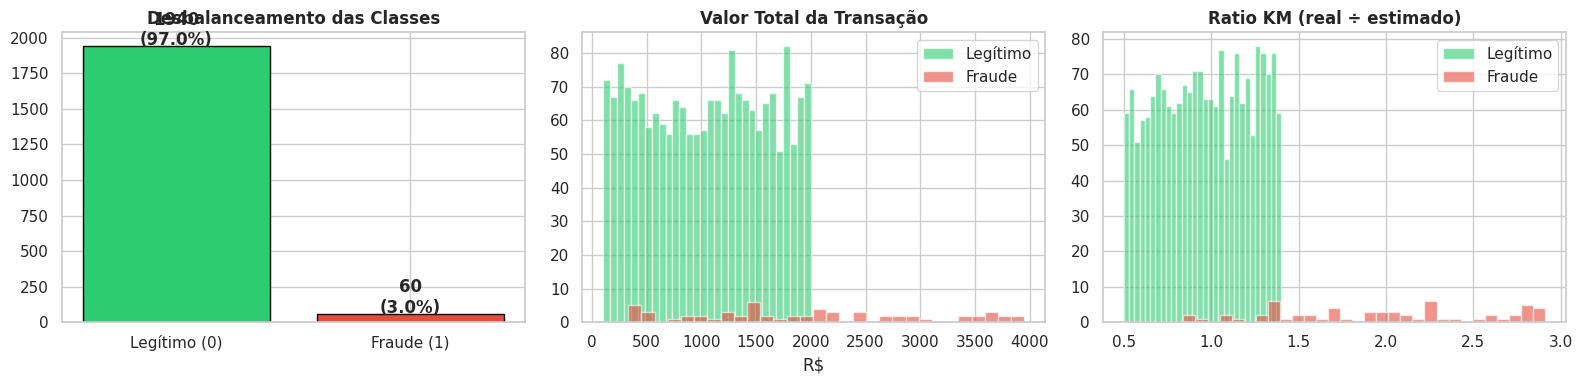

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Desbalanceamento
contagem_f = df_fraude['fraude'].value_counts()
axes[0].bar(['Legítimo (0)', 'Fraude (1)'], contagem_f.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Desbalanceamento das Classes', fontweight='bold')
for i, v in enumerate(contagem_f.values):
    axes[0].text(i, v + 5, f'{v}\n({v/N2*100:.1f}%)', ha='center', fontweight='bold')

# 2. Valor total — legítimo vs fraude
df_fraude[df_fraude['fraude']==0]['valor_total'].hist(
    ax=axes[1], bins=30, alpha=0.6, label='Legítimo', color='#2ecc71')
df_fraude[df_fraude['fraude']==1]['valor_total'].hist(
    ax=axes[1], bins=30, alpha=0.6, label='Fraude', color='#e74c3c')
axes[1].set_title('Valor Total da Transação', fontweight='bold')
axes[1].set_xlabel('R$')
axes[1].legend()

# 3. Ratio KM
df_fraude[df_fraude['fraude']==0]['ratio_km'].hist(
    ax=axes[2], bins=30, alpha=0.6, label='Legítimo', color='#2ecc71')
df_fraude[df_fraude['fraude']==1]['ratio_km'].hist(
    ax=axes[2], bins=30, alpha=0.6, label='Fraude', color='#e74c3c')
axes[2].set_title('Ratio KM (real ÷ estimado)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

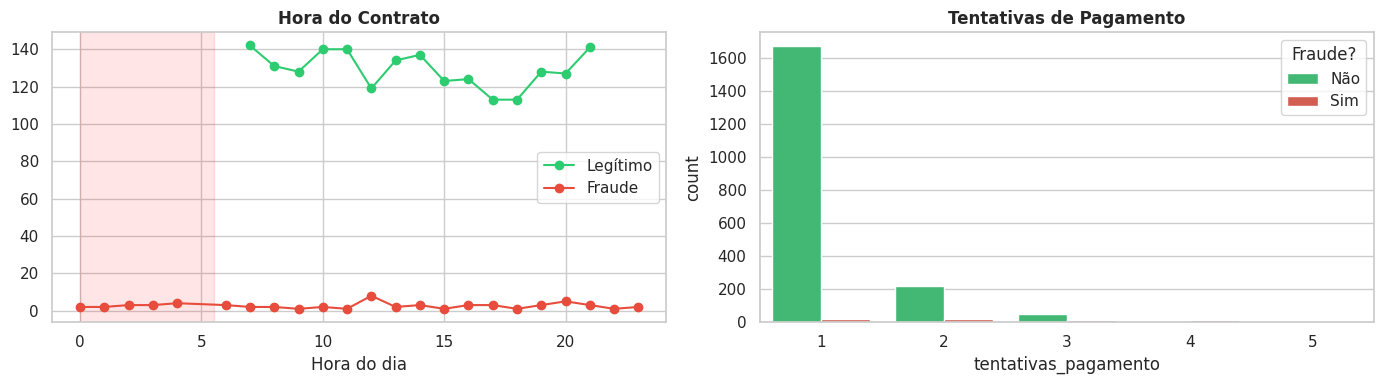

💡 Perceba: fraudes acontecem mais de madrugada e têm mais tentativas de pagamento!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hora do contrato
hora_legitimo = df_fraude[df_fraude['fraude']==0]['hora_contrato'].value_counts().sort_index()
hora_fraude   = df_fraude[df_fraude['fraude']==1]['hora_contrato'].value_counts().sort_index()
axes[0].plot(hora_legitimo.index, hora_legitimo.values, 'o-', color='#2ecc71', label='Legítimo')
axes[0].plot(hora_fraude.index, hora_fraude.values, 'o-', color='#e74c3c', label='Fraude')
axes[0].set_title('Hora do Contrato', fontweight='bold')
axes[0].set_xlabel('Hora do dia')
axes[0].legend()
axes[0].axvspan(0, 5.5, alpha=0.1, color='red', label='Madrugada suspeita')

# Tentativas de pagamento
sns.countplot(data=df_fraude, x='tentativas_pagamento', hue='fraude',
              palette={0:'#2ecc71', 1:'#e74c3c'}, ax=axes[1])
axes[1].set_title('Tentativas de Pagamento', fontweight='bold')
axes[1].legend(title='Fraude?', labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()

print('💡 Perceba: fraudes acontecem mais de madrugada e têm mais tentativas de pagamento!')

---
## 12. O problema da acurácia — modelo "burro"

Vamos demonstrar na prática por que **acurácia não serve** pra avaliar detecção de fraude com dados desbalanceados.

In [ ]:
from sklearn.dummy import DummyClassifier

X_f = df_fraude.drop(columns=['fraude'])
y_f = df_fraude['fraude']

X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)

# Modelo "burro": sempre diz que não é fraude
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_f_train, y_f_train)
y_dummy = dummy.predict(X_f_test)

print('=== Modelo BURRO (sempre diz: não é fraude) ===')
print(f'Acurácia: {accuracy_score(y_f_test, y_dummy)*100:.1f}%  ← parece ótimo né?')
print()
print(classification_report(y_f_test, y_dummy, target_names=['Legítimo', 'Fraude']))
print('⚠️  Recall de fraude = 0.00 → nunca pegou uma fraude sequer!')
print('    Por isso acurácia sozinha não serve aqui.')

=== Modelo BURRO (sempre diz: não é fraude) ===
Acurácia: 97.0%  ← parece ótimo né?

              precision    recall  f1-score   support

    Legítimo       0.97      1.00      0.98       388
      Fraude       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400

⚠️  Recall de fraude = 0.00 → nunca pegou uma fraude sequer!
    Por isso acurácia sozinha não serve aqui.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
## 13. Estratégias para lidar com o desbalanceamento

### Estratégia A: `class_weight='balanced'`
Diz pro modelo: *"errar numa fraude custa mais caro do que errar numa transação legítima"*. O modelo ajusta internamente os pesos de cada classe.

### Estratégia B: SMOTE (Synthetic Minority Oversampling Technique)
Cria **amostras sintéticas** da classe minoritária (fraudes) interpolando entre exemplos existentes. O dataset de treino fica balanceado antes de entrar no modelo.

> **Importante:** o SMOTE é aplicado **só no treino**. O conjunto de teste fica com a distribuição original (realista).

In [ ]:
scaler_f = StandardScaler()
X_f_train_scaled = scaler_f.fit_transform(X_f_train)
X_f_test_scaled  = scaler_f.transform(X_f_test)

print('Distribuição ANTES do SMOTE:')
print(pd.Series(y_f_train).value_counts().to_string())

# Aplicando SMOTE só no treino
smote = SMOTE(random_state=42)
X_f_smote, y_f_smote = smote.fit_resample(X_f_train_scaled, y_f_train)

print('\nDistribuição DEPOIS do SMOTE:')
print(pd.Series(y_f_smote).value_counts().to_string())
print(f'\nO treino foi de {len(y_f_train)} para {len(y_f_smote)} amostras — fraudes sintéticas criadas!')

Distribuição ANTES do SMOTE:
fraude
0    1552
1      48

Distribuição DEPOIS do SMOTE:
fraude
0    1552
1    1552

O treino foi de 1600 para 3104 amostras — fraudes sintéticas criadas!


In [ ]:
# --- Modelo A: Random Forest com class_weight='balanced' ---
rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_bal.fit(X_f_train_scaled, y_f_train)
y_pred_bal = rf_bal.predict(X_f_test_scaled)

print('=== Modelo A: Random Forest com class_weight=balanced ===')
print(classification_report(y_f_test, y_pred_bal, target_names=['Legítimo', 'Fraude']))

# --- Modelo B: Random Forest com SMOTE ---
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_f_smote, y_f_smote)
y_pred_smote = rf_smote.predict(X_f_test_scaled)

print('=== Modelo B: Random Forest + SMOTE ===')
print(classification_report(y_f_test, y_pred_smote, target_names=['Legítimo', 'Fraude']))

=== Modelo A: Random Forest com class_weight=balanced ===
              precision    recall  f1-score   support

    Legítimo       0.99      1.00      1.00       388
      Fraude       1.00      0.75      0.86        12

    accuracy                           0.99       400
   macro avg       1.00      0.88      0.93       400
weighted avg       0.99      0.99      0.99       400

=== Modelo B: Random Forest + SMOTE ===
              precision    recall  f1-score   support

    Legítimo       0.99      1.00      1.00       388
      Fraude       0.91      0.83      0.87        12

    accuracy                           0.99       400
   macro avg       0.95      0.92      0.93       400
weighted avg       0.99      0.99      0.99       400



---
## 14. Métricas certas para fraude: ROC-AUC e Curva Precision-Recall

Além do F1, duas métricas são muito usadas em detecção de fraude:

- **ROC-AUC**: mede a capacidade do modelo de separar as classes. Vai de 0.5 (chute aleatório) a 1.0 (perfeito).
- **Curva Precision-Recall**: mais informativa que ROC quando as classes são muito desbalanceadas. Mostra o tradeoff: quanto mais você quer pegar fraudes (recall alto), mais falsos alarmes você gera (precision cai).

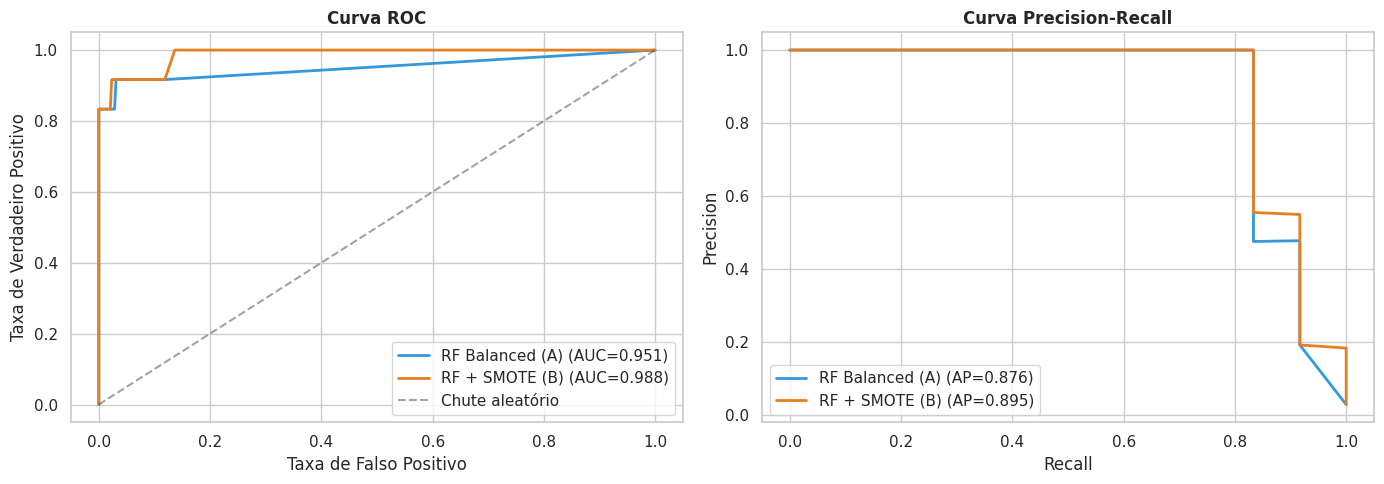

💡 Quanto mais a curva ROC se afasta da diagonal, melhor.
   Na Precision-Recall, quanto maior a área sob a curva, melhor.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_eval = {
    'RF Balanced (A)':  (rf_bal,   X_f_test_scaled),
    'RF + SMOTE (B)':   (rf_smote, X_f_test_scaled),
}
cores = ['#3498db', '#e67e22']

for (nome, (modelo, X_eval)), cor in zip(modelos_eval.items(), cores):
    probs = modelo.predict_proba(X_eval)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_f_test, probs)
    auc = roc_auc_score(y_f_test, probs)
    axes[0].plot(fpr, tpr, color=cor, lw=2, label=f'{nome} (AUC={auc:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_f_test, probs)
    ap = average_precision_score(y_f_test, probs)
    axes[1].plot(rec, prec, color=cor, lw=2, label=f'{nome} (AP={ap:.3f})')

# Linha baseline ROC
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Chute aleatório')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curva ROC', fontweight='bold', fontsize=12)
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 Quanto mais a curva ROC se afasta da diagonal, melhor.')
print('   Na Precision-Recall, quanto maior a área sob a curva, melhor.')

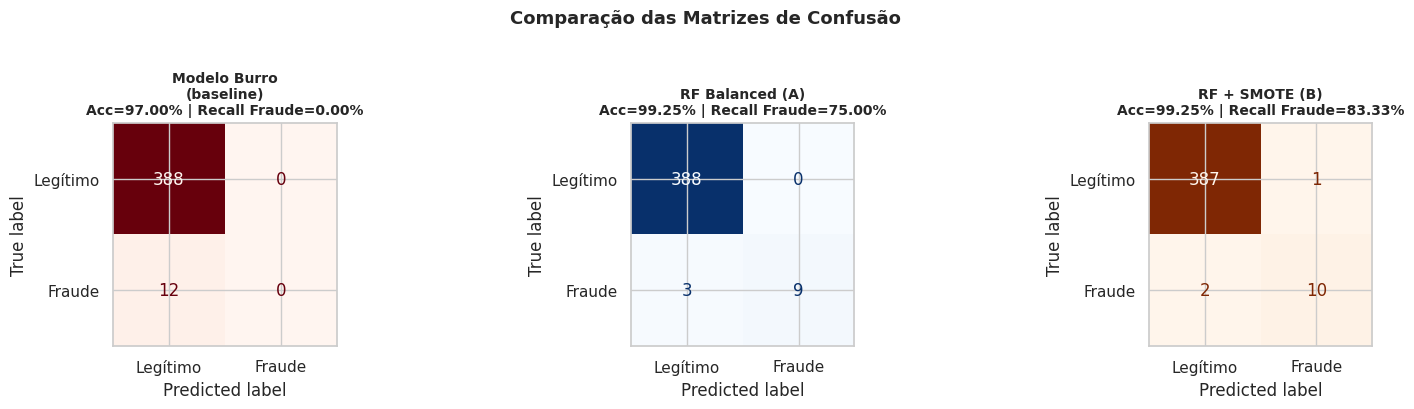

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pares = [
    ('Modelo Burro\n(baseline)', y_dummy,      'Reds'),
    ('RF Balanced (A)',          y_pred_bal,   'Blues'),
    ('RF + SMOTE (B)',           y_pred_smote, 'Oranges'),
]

for ax, (titulo, y_pred, cmap) in zip(axes, pares):
    cm = confusion_matrix(y_f_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítimo', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y_f_test, y_pred)
    rec = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    ax.set_title(f'{titulo}\nAcc={acc:.2%} | Recall Fraude={rec:.2%}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Comparação das Matrizes de Confusão', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

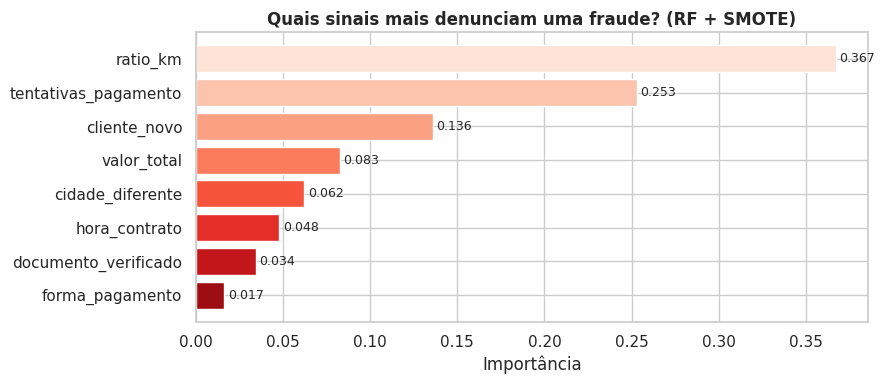

In [ ]:
# Importância das features — qual sinal mais denuncia uma fraude?
importancias_f = pd.Series(rf_smote.feature_importances_, index=X_f.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 4))
bars = plt.barh(importancias_f.index, importancias_f.values,
                color=sns.color_palette('Reds_r', len(importancias_f)))
plt.xlabel('Importância')
plt.title('Quais sinais mais denunciam uma fraude? (RF + SMOTE)', fontweight='bold', fontsize=12)
for bar, val in zip(bars, importancias_f.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 15. Testando com uma transação suspeita

Vamos ver se o modelo consegue pegar uma transação com vários sinais de alerta.

In [ ]:
transacoes_teste = pd.DataFrame([
    {
        'descricao':             '⚠️  Transação SUSPEITA',
        'valor_total':           4200,   # alto
        'tentativas_pagamento':  4,      # muitas tentativas
        'cliente_novo':          1,      # nunca alugou
        'documento_verificado':  0,      # documento não OK
        'cidade_diferente':      1,      # quer devolver em outra cidade
        'ratio_km':              3.2,    # km muito acima do estimado
        'hora_contrato':         2,      # madrugada
        'forma_pagamento':       0,      # crédito
    },
    {
        'descricao':             '✅  Transação NORMAL',
        'valor_total':           450,    # valor ok
        'tentativas_pagamento':  1,      # pagou de primeira
        'cliente_novo':          0,      # cliente antigo
        'documento_verificado':  1,      # documento ok
        'cidade_diferente':      0,      # devolve no mesmo lugar
        'ratio_km':              0.9,    # km dentro do normal
        'hora_contrato':         10,     # horário comercial
        'forma_pagamento':       2,      # pix
    }
])

descricoes = transacoes_teste.pop('descricao')
t_scaled   = scaler_f.transform(transacoes_teste)
probs_pred = rf_smote.predict_proba(t_scaled)[:, 1]

print('=== Resultado das previsões ===')
for desc, prob in zip(descricoes, probs_pred):
    alerta = '🚨 BLOQUEADA' if prob > 0.5 else '✅ APROVADA'
    print(f'{desc}')
    print(f'  → Probabilidade de fraude: {prob*100:.1f}% — {alerta}')
    print()

=== Resultado das previsões ===
⚠️  Transação SUSPEITA
  → Probabilidade de fraude: 100.0% — 🚨 BLOQUEADA

✅  Transação NORMAL
  → Probabilidade de fraude: 0.0% — ✅ APROVADA



---
## 16. Conclusão Final

### Resumo das duas partes:

| | Parte 1 — Atraso | Parte 2 — Fraude |
|---|---|---|
| **Problema** | Classificação binária | Classificação binária |
| **Dificuldade extra** | Classes relativamente balanceadas | Classes **muito** desbalanceadas |
| **Métrica principal** | Acurácia + F1 | Recall de fraude + ROC-AUC |
| **Técnica especial** | — | class_weight / SMOTE |
| **Modelo vencedor** | Random Forest | Random Forest + SMOTE |

### O que aprendemos na Parte 2:
- ✅ Acurácia é uma métrica enganosa quando as classes são desbalanceadas
- ✅ `class_weight='balanced'` é a solução mais simples e funciona bem
- ✅ SMOTE cria amostras sintéticas pra equilibrar o treino
- ✅ ROC-AUC e Precision-Recall são as métricas certas pra esse tipo de problema
- ✅ Features como `ratio_km`, `valor_total` e `documento_verificado` são fortes sinais de fraude

### Próximos passos:
1. **Threshold customizado** — em vez de usar 0.5 como corte, ajustar o limiar pra maximizar recall de fraudes
2. **Isolation Forest** — algoritmo não supervisionado especializado em detecção de anomalias
3. **XGBoost / LightGBM** — modelos boosting que costumam superar o Random Forest
4. **Feature engineering** — criar novas features a partir das existentes (ex: valor_por_km)

---
*Dataset gerado artificialmente com `numpy.random` para fins educacionais.*